# Figure S10 — CCA Analysis and Plots
Generates `figureS10.png` and `.pdf` directly via matplotlib.

- **Panel a**: CCA weighted gene score (coronal + sagittal)
- **Panel b**: CI width 95% (coronal + sagittal)
- **Panel c**: Top 16 correlated genes (4×4 grid, coronal + sagittal each)

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.transforms as mtransforms
import scanpy as sc
from scipy.stats import spearmanr
from sklearn.cross_decomposition import CCA
from functools import partial
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.colors import LinearSegmentedColormap

# Add parent directory to path
notebook_dir = os.path.dirname(os.path.abspath(''))
if notebook_dir not in sys.path:
    sys.path.append(os.path.dirname(notebook_dir))

from notebooks.config import *
import processing, utils, plotting
import spatial_cca, imputations

configure_matplotlib()
SAVE_FIGURES = True
fig_path = MERFISH_FIGURE_DIR
save_figure = partial(save_figure, dir_path=fig_path)
cpm_scl = CPM_SCL_MERFISH

print(f"scanpy version: {sc.__version__}")

PROJECT_ROOT: /code/
CODE_DIR: /code/
CODE_DIR exists: True
Python path includes CODE_DIR: True
scanpy version: 1.11.3


## Data Loading and Preprocessing

In [2]:
MERFISH_DATA_DIR

'/data/LC_NE_preprocessed/merfish/'

In [3]:
# ── Load mesh ───────────────────────────────────────────────────────
allmeshes = utils.load_mesh(MESH_DIR, nameconstrains='*new_core*')
mesh = allmeshes['new_core_mesh']
mesh.vertices = mesh.vertices[:, [1, 2, 0]]
mesh.vertices /= 25
mesh_mirror = processing.make_bilateral_mesh_from_ref(mesh, MESH_DIR_sym)

# ── Load MERFISH ────────────────────────────────────────────────────
filename = os.path.join(MERFISH_DATA_DIR, 'adata_mer_subset_2_2k.h5ad')
adata_mer = sc.read_h5ad(filename)
librarysize = np.sum(adata_mer.X, 1)
adata_mer.X = 1000 * adata_mer.X / librarysize[:, None]

# Filter
y = adata_mer.obsm['spatial'][:, 1]
keep = y <= 220
print(f"Removing {(~keep).sum()} cells with DV axis > 220")
adata_mer = adata_mer[keep].copy()
print(f"After filtering: {adata_mer.shape}")

# # UMAP
# sc.pp.neighbors(adata_mer, use_rep='X_scVI', random_state=307)
# sc.tl.umap(adata_mer, random_state=210)

Removing 51 cells with DV axis > 220
After filtering: (2204, 315)


## CCA Analysis

In [4]:
scl_multiplier = 25

S_mer_fo_cca = processing.get_hemi(adata_mer.obsm['spatial'], MESH_DIR_sym)
cca, X_c, S_c, canonical_correlations = spatial_cca.perform_cca(
    adata_mer.X, S_mer_fo_cca,
    n_components=2, scl_multiplier=scl_multiplier)
print(f"Canonical correlations: {canonical_correlations}")

# Spatial variables for plotting
s = 10
k = 0
scale_factor = 1 * scl_multiplier
vector = cca.y_weights_[:, k]
vector_unit = vector / np.linalg.norm(vector)
arrow_length = 15  # data units
vector_scaled = vector_unit * arrow_length

allspatial = adata_mer.obsm['spatial'].copy()
allspatial_j_ML = plotting.add_jitter(allspatial, scl_jitter=0.05)
allspatial_j = processing.get_hemi(allspatial_j_ML, MESH_DIR_sym)

Canonical correlations: [0.8013287510240753, 0.613186055920211]


## Gene Correlations & Colormaps

In [5]:
# Gene correlations with CCA component 0
w = cca.x_weights_[:, 0]
genes = np.array(adata_mer.var_names)
score = X_c[:, 0]
X = adata_mer.X.toarray() if hasattr(adata_mer.X, 'toarray') else np.array(adata_mer.X)

corrs = [spearmanr(X[:, j], score)[0] for j in range(X.shape[1])]
df_gene_corr = pd.DataFrame({
    'gene': genes, 'gene_weight': w,
    'spearman_corr': corrs, 'abs_corr': np.abs(corrs)
}).sort_values('abs_corr', ascending=False)
print(df_gene_corr.head(10))

# Colormaps
cmap_sele = plt.get_cmap(CMAP_NAME)
low_col = cmap_sele(0.0)
high_col = cmap_sele(1.0)
low_cmap = LinearSegmentedColormap.from_list('low_cmap', ['white', low_col])
high_cmap = LinearSegmentedColormap.from_list('high_cmap', ['white', high_col])

       gene  gene_weight  spearman_corr  abs_corr
269   Tacr3     0.131090       0.630329  0.630329
197    Pdyn    -0.129018      -0.578749  0.578749
163    Nefm     0.329837       0.548153  0.548153
44    Chodl    -0.161869      -0.497024  0.497024
183   Oprm1    -0.162463      -0.491128  0.491128
194  Pde11a    -0.106629      -0.362819  0.362819
281    Trhr    -0.085247      -0.361154  0.361154
162    Nefl     0.173852       0.357128  0.357128
81    Ecel1     0.271198       0.349264  0.349264
273      Th     0.061267       0.333341  0.333341


## Pseudocluster Imputation (for panel b)

In [6]:
TMP_OUT_DIR

'/results/'

In [7]:
os.path.exists('/code')

True

In [9]:
# Load scRNA-seq and impute
snrna_data_path = os.path.join(SNRNA_DATA_DIR, 'snRNAseq_LCNE_BN_d4_merbar_1-5k.h5ad')
adata_foo = sc.read_h5ad(snrna_data_path)
adata_sc = sc.AnnData(adata_foo.layers['BN'])
adata_sc.obs = adata_foo.obs.copy()
adata_sc.obsm = adata_foo.obsm.copy()
adata_sc.var = adata_foo.var.copy()

# Pseudocluster imputation
common_genes_mer = np.intersect1d(adata_mer.var_names, adata_sc.var_names)
adata_mer_subset = adata_mer[:, common_genes_mer]
imp_mer, conf_mer = imputations.impute_pseudocluster(
    adata_mer_subset, adata_sc, pc_dir=TMP_OUT_DIR, k=100,
    similarity_transform='softmax')
adata_mer.obs['imputed pseudocluster'] = imp_mer
print('Imputation done')

using 304 genes to run the imputations!
Imputation done


## Build Composite Figure (a + b + c)

In [10]:
# Compare mesh rendering: triplot-only vs tripcolor depth-shading
from matplotlib.tri import Triangulation

# fig_test, axes = plt.subplots(2, 3, figsize=(12, 6), dpi=300)
# fig_test.suptitle("Mesh depth-shading comparison (coronal view)", fontsize=10)

tri_cor = Triangulation(mesh.vertices[:, 2], mesh.vertices[:, 1], mesh.faces)
tri_sag = Triangulation(mesh.vertices[:, 0], mesh.vertices[:, 1], mesh.faces)

# Face normals → Lambertian shading for coronal (view along AP = axis 0)
face_normals = mesh.face_normals  # trimesh recomputes from current vertices
shade_cor = np.abs(face_normals[:, 0])  # how much each face "faces" the coronal viewer
shade_cor = 1.0 - shade_cor              # invert: edge-on faces → dark, facing → light

configs = [
    ("previous: triplot lw=0.05 α=0.10",
     lambda ax: ax.triplot(tri_cor, color='gray', lw=0.05, alpha=0.10, rasterized=True)),
    ("current: triplot lw=0.08 α=0.20",
     lambda ax: ax.triplot(tri_cor, color='gray', lw=0.08, alpha=0.20, rasterized=True)),
    ("tripcolor shade α=0.15",
     lambda ax: ax.tripcolor(tri_cor, facecolors=shade_cor, cmap='gray',
                              alpha=0.15, rasterized=True, edgecolors='none')),
    ("tripcolor α=0.15 + triplot lw=0.03 α=0.08",
     lambda ax: [ax.tripcolor(tri_cor, facecolors=shade_cor, cmap='gray',
                               alpha=0.15, rasterized=True, edgecolors='none'),
                 ax.triplot(tri_cor, color='gray', lw=0.03, alpha=0.08, rasterized=True)]),
    ("tripcolor α=0.20 + triplot lw=0.03 α=0.06",
     lambda ax: [ax.tripcolor(tri_cor, facecolors=shade_cor, cmap='gray',
                               alpha=0.20, rasterized=True, edgecolors='none'),
                 ax.triplot(tri_cor, color='gray', lw=0.03, alpha=0.06, rasterized=True)]),
    ("tripcolor α=0.25 + triplot lw=0.02 α=0.05",
     lambda ax: [ax.tripcolor(tri_cor, facecolors=shade_cor, cmap='gray',
                               alpha=0.25, rasterized=True, edgecolors='none'),
                 ax.triplot(tri_cor, color='gray', lw=0.02, alpha=0.05, rasterized=True)]),
]

# for ax, (label, draw_fn) in zip(axes.flat, configs):
#     draw_fn(ax)
#     ax.set_xlim(cor_xlim); ax.set_ylim(ylim)
#     ax.set_aspect('equal', adjustable='box')
#     ax.set_title(label, fontsize=7)
#     ax.set_xticks([]); ax.set_yticks([])

# fig_test.tight_layout()
# plt.show()

In [11]:
import tempfile
from fontTools.ttLib import TTCollection
from matplotlib.tri import Triangulation

# Pre-build triangulations for coronal and sagittal mesh projections
tri_cor = Triangulation(mesh.vertices[:, 2], mesh.vertices[:, 1], mesh.faces)
tri_sag = Triangulation(mesh.vertices[:, 0], mesh.vertices[:, 1], mesh.faces)

# Face-normal Lambertian shading: edge-on faces → dark, viewer-facing → light
_fn = mesh.face_normals
shade_cor = 1.0 - np.abs(_fn[:, 0])  # coronal viewer looks along axis 0
shade_sag = 1.0 - np.abs(_fn[:, 2])  # sagittal viewer looks along axis 2

# ══════════════════════════════════════════════════════════════════════
# Font setup
# ══════════════════════════════════════════════════════════════════════
helvetica_path = os.path.join(PROJECT_ROOT, 'utils', 'Helvetica.ttc')
helvetica_prop = fm.FontProperties(fname=helvetica_path, size=7)
fm.fontManager.addfont(helvetica_path)

# Bold for panel labels
_bold_ttf = os.path.join(tempfile.gettempdir(), 'HelveticaBold.ttf')
if not os.path.exists(_bold_ttf):
    TTCollection(helvetica_path).fonts[1].save(_bold_ttf)
helvetica_bold = fm.FontProperties(fname=_bold_ttf, size=12)

# Oblique for gene names
oblique_path = os.path.join(PROJECT_ROOT, 'utils', 'Helvetica-Oblique.ttf')
if not os.path.exists(oblique_path):
    TTCollection(helvetica_path).fonts[2].save(oblique_path)
helvetica_oblique = fm.FontProperties(fname=oblique_path, size=8)

plt.rcParams.update({
    'font.family': 'Helvetica', 'font.size': 7,
    'axes.labelsize': 7, 'axes.titlesize': 7,
    'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

1 extra bytes in post.stringData array
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array


Saved PDF: /results/figures/merfish/figureS10.pdf
Saved PNG: /results/figures/merfish/figureS10.png


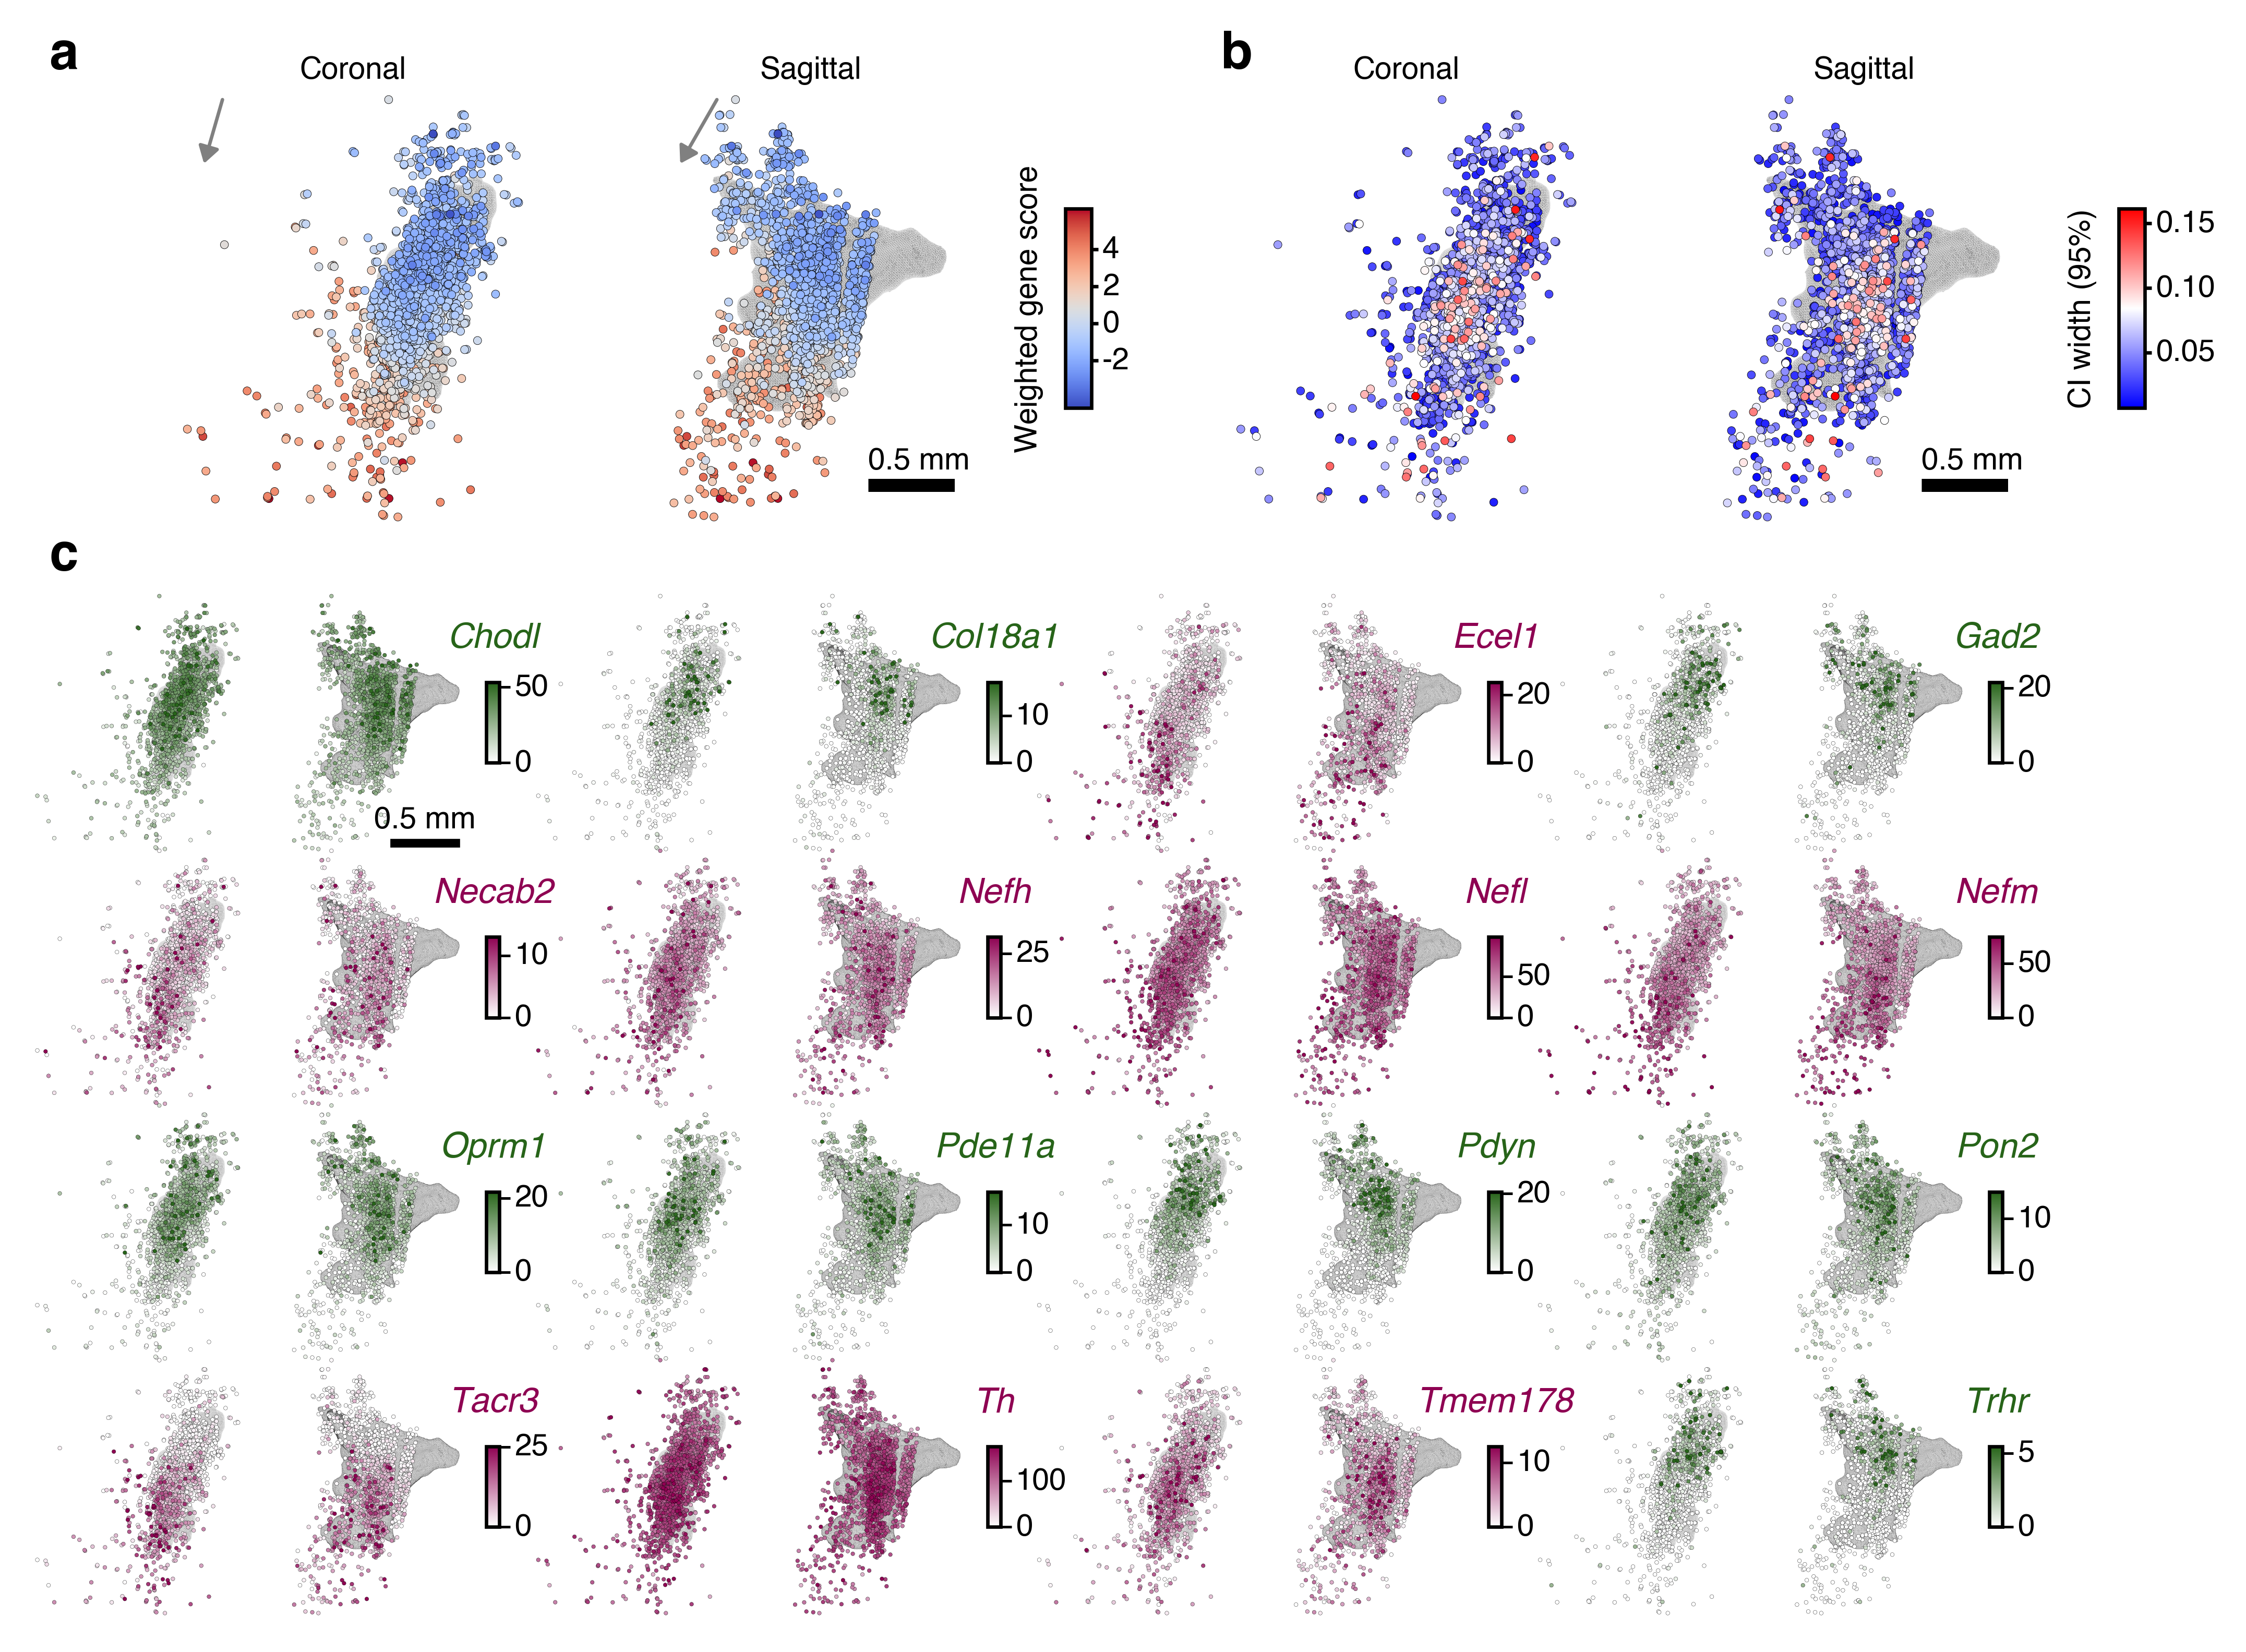

In [12]:


# ══════════════════════════════════════════════════════════════════════
# Shared spatial extents
# ══════════════════════════════════════════════════════════════════════
start_point_all = np.min(allspatial, 0)
start_point_j = np.min(allspatial_j, 0)

cor_x_data = np.concatenate([mesh.vertices[:, 2], allspatial_j[:, 2]])
sag_x_data = np.concatenate([mesh.vertices[:, 0], allspatial_j[:, 0]])
all_y_data = np.concatenate([mesh.vertices[:, 1], allspatial_j[:, 1]])

cor_xmin, cor_xmax = cor_x_data.min(), cor_x_data.max()
sag_xmin, sag_xmax = sag_x_data.min(), sag_x_data.max()
ymin, ymax = all_y_data.min(), all_y_data.max()

margin = 0.03
cor_dx = cor_xmax - cor_xmin; sag_dx = sag_xmax - sag_xmin; dy = ymax - ymin
cor_xlim = (cor_xmin - margin * cor_dx, cor_xmax + margin * cor_dx)
sag_xlim = (sag_xmin - margin * sag_dx, sag_xmax + margin * sag_dx)
ylim = (ymax + margin * dy, ymin - margin * dy)  # inverted (dorsal up)

cor_x_range = cor_xlim[1] - cor_xlim[0]
sag_x_range = sag_xlim[1] - sag_xlim[0]
y_range = abs(ylim[1] - ylim[0])
ratio_cor = cor_x_range / y_range
ratio_sag = sag_x_range / y_range
cbar_w_ratio = 0.03

# ══════════════════════════════════════════════════════════════════════
# Gene list for panel c
# ══════════════════════════════════════════════════════════════════════
G = 16
_df_top = df_gene_corr[:G].copy().sort_values('gene')
gene_list = _df_top.gene.values.tolist()
gene_is_low = _df_top['spearman_corr'].values > 0

# Override scatter size for panels a & b (smaller dots)
s = 3.5

# ══════════════════════════════════════════════════════════════════════
# Figure layout: US Letter, 1" margins → 6.5 × 9" usable
#   Row 0 : panels a + b  (height ~ 2.0")
#   Rows 1-4 : panel c  (4×4 gene grid, remaining height)
# ══════════════════════════════════════════════════════════════════════
fig_width = 6.5
fig_height = 5.0

# Height allocation
ab_height_frac = 0.30   # fraction of figure for panels a+b
c_height_frac = 1.0 - ab_height_frac
fig = plt.figure(figsize=(fig_width, fig_height))
fig.set_dpi(600)  # rasterized elements render at 600 DPI
fig.patch.set_facecolor('none')
fig.patch.set_alpha(0.0)
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)

# Top-level grid: 2 rows (ab row, c row)
outer = GridSpec(2, 1, figure=fig,
                 height_ratios=[ab_height_frac, c_height_frac],
                 hspace=0.08,
                 left=0.01, right=0.99, top=0.99, bottom=0.01)


# ──────────────────────────────────────────────────────────────────────
# Helper: draw one spatial pair (coronal + sagittal + colorbar)
# ──────────────────────────────────────────────────────────────────────
def draw_spatial_pair(fig, subplot_spec, color_vals, cmap, sort_ascending,
                      cbar_label, cbar_fmt='auto', cbar_ticks=None,
                      arrow_vector=None, panel_label=None, add_scale_bar=True):
    """Draw coronal+sagittal+colorbar into *subplot_spec*."""
    inner = GridSpecFromSubplotSpec(
        1, 3, subplot_spec=subplot_spec,
        width_ratios=[ratio_cor, ratio_sag, cbar_w_ratio], wspace=-0.4)

    ax_cor = fig.add_subplot(inner[0, 0])
    ax_sag = fig.add_subplot(inner[0, 1], sharey=ax_cor)
    cax = fig.add_subplot(inner[0, 2])

    order = np.argsort(color_vals)
    if not sort_ascending:
        order = order[::-1]

    ax_cor.tripcolor(tri_cor, facecolors=shade_cor, cmap='gray',
                     alpha=0.08, rasterized=True, edgecolors='none')
    ax_cor.triplot(tri_cor, color='gray', lw=0.03, alpha=0.04, rasterized=True)
    sca = plotting.scatter_with_jitter(
        ax_cor, allspatial_j[order], color_vals[order],
        direction='c', s=s, lw=0.1, scl_jitter=0,
        ascending=sort_ascending, cmap=cmap)

    # Arrow on coronal panel
    if arrow_vector is not None:
        cor_arrow_x = start_point_j[2] + 0.10 * (cor_xlim[1] - cor_xlim[0])
        sp_c = (cor_arrow_x, start_point_j[1])
        ep_c = (cor_arrow_x + arrow_vector[2], start_point_j[1] + arrow_vector[1])
        ax_cor.annotate('', xy=ep_c, xytext=sp_c,
                        arrowprops=dict(arrowstyle='-|>,head_length=0.4,head_width=0.25',
                                        color='gray', lw=0.8,
                                        mutation_scale=8,
                                        shrinkA=0, shrinkB=0), zorder=10)

    ax_cor.set_xlim(cor_xlim); ax_cor.set_ylim(ylim)
    ax_cor.set_aspect('equal', adjustable='box')
    ax_cor.set_title('Coronal', fontproperties=helvetica_prop, pad=2)
    ax_cor.set_xlabel(''); ax_cor.set_ylabel('')
    ax_cor.set_xticks([]); ax_cor.set_yticks([])
    for sp in ax_cor.spines.values(): sp.set_visible(False)

    # Sagittal
    ax_sag.tripcolor(tri_sag, facecolors=shade_sag, cmap='gray',
                     alpha=0.08, rasterized=True, edgecolors='none')
    ax_sag.triplot(tri_sag, color='gray', lw=0.03, alpha=0.04, rasterized=True)
    plotting.scatter_with_jitter(
        ax_sag, allspatial_j[order], color_vals[order],
        direction='s', s=s, lw=0.1, scl_jitter=0,
        ascending=sort_ascending, cmap=cmap)

    # Arrow on sagittal panel
    if arrow_vector is not None:
        sag_arrow_x = sag_xlim[0] + 0.05 * (sag_xlim[1] - sag_xlim[0]) - min(0, arrow_vector[0])
        sp_s = (sag_arrow_x, start_point_all[1])
        ep_s = (sag_arrow_x + arrow_vector[0], start_point_all[1] + arrow_vector[1])
        ax_sag.annotate('', xy=ep_s, xytext=sp_s,
                        arrowprops=dict(arrowstyle='-|>,head_length=0.4,head_width=0.25',
                                        color='gray', lw=0.8,
                                        mutation_scale=8,
                                        shrinkA=0, shrinkB=0),
                        annotation_clip=False, zorder=10)

    ax_sag.set_xlim(sag_xlim); ax_sag.set_ylim(ylim)
    ax_sag.set_aspect('equal', adjustable='box')
    ax_sag.set_title('Sagittal', fontproperties=helvetica_prop, pad=2)
    ax_sag.set_xlabel('')
    ax_sag.set_xticks([]); ax_sag.set_yticks([])
    plt.setp(ax_sag.get_yticklabels(), visible=False)
    for sp in ax_sag.spines.values(): sp.set_visible(False)

    # Scale bar with centered '0.5 mm' label above
    if add_scale_bar:
        _xlim = ax_sag.get_xlim(); _ylim = ax_sag.get_ylim()
        _x0 = _xlim[0] + 0.7 * (_xlim[1] - _xlim[0])
        _y0 = _ylim[0] + 0.1 * (_ylim[1] - _ylim[0])
        _bar_len = 20  # pixels; 20 * 25/1000 = 0.5 mm
        ax_sag.plot([_x0, _x0 + _bar_len], [_y0, _y0],
                    color='black', linewidth=3, solid_capstyle='butt')
        ax_sag.text(_x0 + _bar_len / 2, _y0 - 2, '0.5 mm',
                    ha='center', va='bottom', fontproperties=helvetica_prop)

    # Colorbar — shrink to 45% and shift right
    cbar_x_offset = 0.07  # shift colorbar right (figure fraction)
    fig.canvas.draw()
    pos = cax.get_position()
    new_h = pos.height * 0.45
    new_y = pos.y0 + (pos.height - new_h) / 2
    cax.set_position([pos.x0 + cbar_x_offset, new_y, pos.width, new_h])

    cbar = fig.colorbar(sca, cax=cax)
    cbar.ax.tick_params(labelsize=7, pad=2, length=1.5)
    cbar.ax.yaxis.set_ticks_position('right')
    fig.canvas.draw()

    # 1pt gap between tick right border and text left border
    tick_offset = mtransforms.ScaledTranslation(
        (1.5 + 1)/72, 0, fig.dpi_scale_trans)  # tick_length + 1pt gap
    tick_text_transform = mtransforms.blended_transform_factory(
        cbar.ax.transAxes, cbar.ax.transData) + tick_offset

    ticks = cbar.ax.get_yticks()
    if cbar_ticks is not None:
        ticks = np.array(cbar_ticks)
    else:
        # Ensure both ends of range have ticks
        for endpoint in [cbar.vmin, cbar.vmax]:
            if not any(np.isclose(endpoint, ticks)):
                ticks = np.append(ticks, endpoint)
    cbar.ax.set_yticks([t for t in ticks if cbar.vmin <= t <= cbar.vmax])
    cbar.ax.set_yticklabels([])
    for t in ticks:
        if cbar.vmin <= t <= cbar.vmax:
            if cbar_fmt == 'auto':
                lbl = f'{int(t)}' if t == int(t) else f'{t:.1f}'
            else:
                lbl = f'{t:{cbar_fmt}}'
            cbar.ax.text(
                1.0, t, lbl,
                transform=tick_text_transform,
                ha='left', va='center',
                fontproperties=helvetica_prop)
    cbar.ax.yaxis.set_label_position('left')
    cbar.set_label(cbar_label, fontproperties=helvetica_prop,
                   rotation=90, labelpad=5)

    # Panel label
    if panel_label is not None:
        bb = ax_cor.get_position()
        fig.text(bb.x0 - 0.005, bb.y1 + 0.005, panel_label,
                 fontproperties=helvetica_bold, va='bottom', ha='left')

    return ax_cor, ax_sag, cax


# ROW 0 — Panels a and b side-by-side
# ══════════════════════════════════════════════════════════════════════
gs_ab = GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0], wspace=0.12)

# Panel a — CCA weighted gene score
draw_spatial_pair(
    fig, gs_ab[0, 0],
    color_vals=score, cmap='coolwarm', sort_ascending=False,
    cbar_label='Weighted gene score',
    cbar_ticks=[-2, 0, 2, 4],
    arrow_vector=vector_scaled, panel_label=None)

# Panel b — CI width (95%)
ci_width = conf_mer['ci_range']
draw_spatial_pair(
    fig, gs_ab[0, 1],
    color_vals=ci_width, cmap='bwr', sort_ascending=True,
    cbar_label='CI width (95%)', cbar_fmt='.2f',
    cbar_ticks=[0, 0.05, 0.10, 0.15],
    panel_label='b')

# ROW 1 — Panel c (16 genes in 4×4)
# ══════════════════════════════════════════════════════════════════════
n_rows_c, n_cols_c = 4, 4
gs_c = GridSpecFromSubplotSpec(
    n_rows_c, n_cols_c, subplot_spec=outer[1],
    wspace=0.02, hspace=-0.05)

cbar_w_gene = 0.04  # relative colorbar width for gene panels
s_pt = 0.8
s_mesh = 0.001

def rasterize_collections(ax):
    for c in ax.collections:
        c.set_rasterized(True)

for idx in range(G):
    gene = gene_list[idx]
    is_low = gene_is_low[idx]
    row, col = divmod(idx, n_cols_c)

    cmap_use = low_cmap if is_low else high_cmap
    col_use = low_col if is_low else high_col

    vals = cpm_scl * adata_mer[:, gene].X.toarray().flatten()
    plotorder = np.argsort(vals)
    vmax_99 = np.percentile(vals, 99)

    inner = GridSpecFromSubplotSpec(
        1, 3, subplot_spec=gs_c[row, col],
        width_ratios=[ratio_cor, ratio_sag, cbar_w_gene], wspace=0.02)

    ax_cor = fig.add_subplot(inner[0, 0])
    ax_sag = fig.add_subplot(inner[0, 1], sharey=ax_cor)
    cax = fig.add_subplot(inner[0, 2])

    # Coronal
    ax_cor.tripcolor(tri_cor, facecolors=shade_cor, cmap='gray',
                     alpha=0.04, rasterized=True, edgecolors='none')
    ax_cor.triplot(tri_cor, color='gray', lw=0.03, alpha=0.02, rasterized=True)
    sca = plotting.scatter_with_jitter(
        ax_cor, allspatial_j[plotorder], vals[plotorder],
        direction='c', s=s_pt, lw=0.05, scl_jitter=0,
        ascending=True, cmap=cmap_use)
    sca.set_clim(vmin=0, vmax=vmax_99)
    rasterize_collections(ax_cor)

    ax_cor.set_xlim(cor_xlim); ax_cor.set_ylim(ylim)
    ax_cor.set_aspect('equal', adjustable='box')
    ax_cor.set_xlabel(''); ax_cor.set_ylabel('')
    ax_cor.set_xticks([]); ax_cor.set_yticks([])
    ax_cor.patch.set_alpha(0.0)
    for sp in ax_cor.spines.values(): sp.set_visible(False)

    # Sagittal
    ax_sag.tripcolor(tri_sag, facecolors=shade_sag, cmap='gray',
                     alpha=0.04, rasterized=True, edgecolors='none')
    ax_sag.triplot(tri_sag, color='gray', lw=0.03, alpha=0.02, rasterized=True)
    plotting.scatter_with_jitter(
        ax_sag, allspatial_j[plotorder], vals[plotorder],
        direction='s', s=s_pt, lw=0.05, scl_jitter=0,
        ascending=True, cmap=cmap_use)
    for c_art in ax_sag.collections:
        c_art.set_rasterized(True)
        if hasattr(c_art, 'set_clim'):
            c_art.set_clim(vmin=0, vmax=vmax_99)

    ax_sag.set_xlim(sag_xlim); ax_sag.set_ylim(ylim)
    ax_sag.set_aspect('equal', adjustable='box')
    ax_sag.set_xlabel('')
    ax_sag.set_xticks([]); ax_sag.set_yticks([])
    ax_sag.patch.set_alpha(0.0)
    plt.setp(ax_sag.get_yticklabels(), visible=False)
    for sp in ax_sag.spines.values(): sp.set_visible(False)

    # Scale bar on first gene only
    if idx == 0:
        plotting.draw_scale_bar(ax_sag, length_px=20, linewidth=2,
                                px_to_mm=25/1000, loc=(0.6, 0.05))

    # Colorbar
    fig.canvas.draw()
    pos = cax.get_position()
    new_h = pos.height * 0.30
    new_y = pos.y0 + (pos.height - new_h) / 2
    cax.set_position([pos.x0, new_y, pos.width, new_h])

    cbar = fig.colorbar(sca, cax=cax)
    cbar.ax.tick_params(labelsize=7, pad=2, length=2.5, width=0.6, direction='out')
    cbar.ax.yaxis.set_ticks_position('right')
    fig.canvas.draw()

    # 1pt gap between tick right border and text left border
    tick_offset_c = mtransforms.ScaledTranslation(
        (2.5 + 1)/72, 0, fig.dpi_scale_trans)  # tick_length + 1pt gap
    tick_text_transform_c = mtransforms.blended_transform_factory(
        cbar.ax.transAxes, cbar.ax.transData) + tick_offset_c

    ticks = cbar.ax.get_yticks()
    cbar.ax.set_yticklabels([])
    for t in ticks:
        if cbar.vmin <= t <= cbar.vmax:
            lbl = f'{int(t)}' if t == int(t) else f'{t:.1f}'
            cbar.ax.text(
                1.0, t, lbl,
                transform=tick_text_transform_c,
                ha='left', va='center',
                fontproperties=helvetica_prop)

    cbar.ax.set_title(gene, fontproperties=helvetica_oblique,
                      color=col_use, pad=8, fontsize=8)

# Panel c label
# Place a and c at the same horizontal coordinate
fig.canvas.draw()
gs_c_pos = gs_c[0, 0].get_position(fig)
bb_a = fig.axes[0].get_position()  # coronal axes of panel a
label_x = min(bb_a.x0, gs_c_pos.x0) + 0.02
fig.text(label_x, bb_a.y1 + 0.005, 'a',
         fontproperties=helvetica_bold, va='bottom', ha='left')
fig.text(label_x, gs_c_pos.y1 + 0.005, 'c',
         fontproperties=helvetica_bold, va='bottom', ha='left')

# ══════════════════════════════════════════════════════════════════════
# Save
# ══════════════════════════════════════════════════════════════════════
out_base = os.path.join(fig_path, 'figureS10')

fig.savefig(out_base + '.pdf', dpi=600, format='pdf',
            transparent=True, bbox_inches='tight', pad_inches=0.02)
print(f'Saved PDF: {out_base}.pdf')

fig.savefig(out_base + '.png', dpi=600, format='png',
            transparent=True,
            bbox_inches='tight', pad_inches=0.02)
print(f'Saved PNG: {out_base}.png')

# plt.show()